--PUNTOS 1 Y 2: Formas basicas y TDF


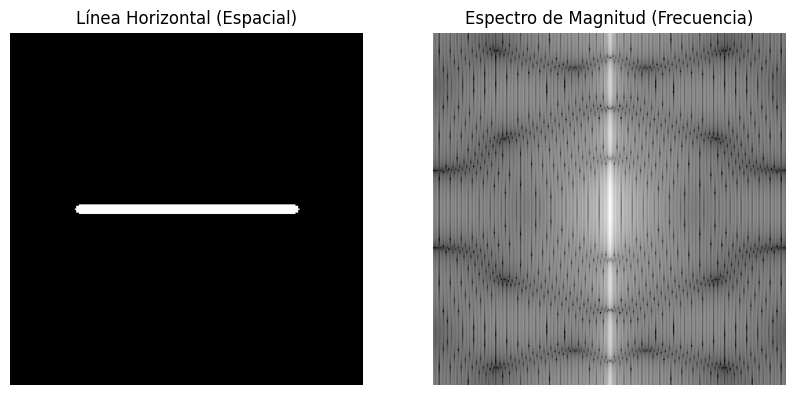

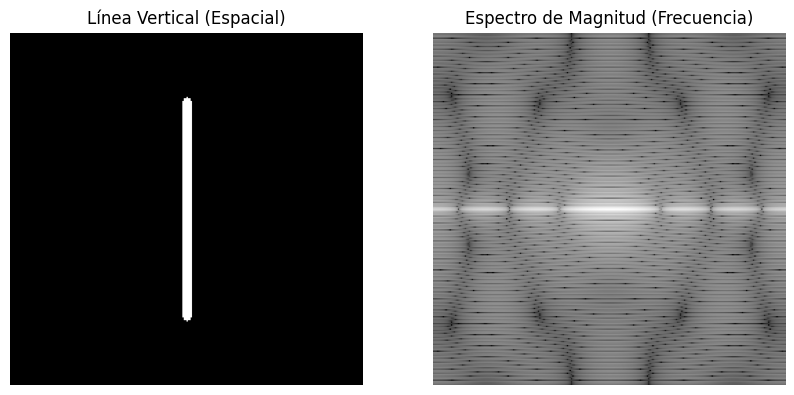

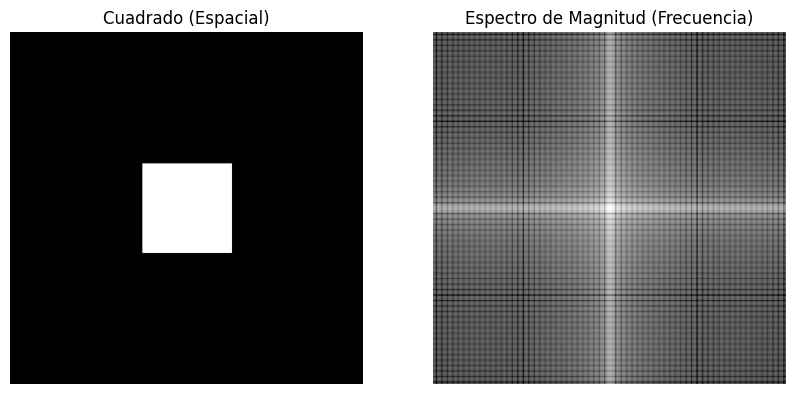

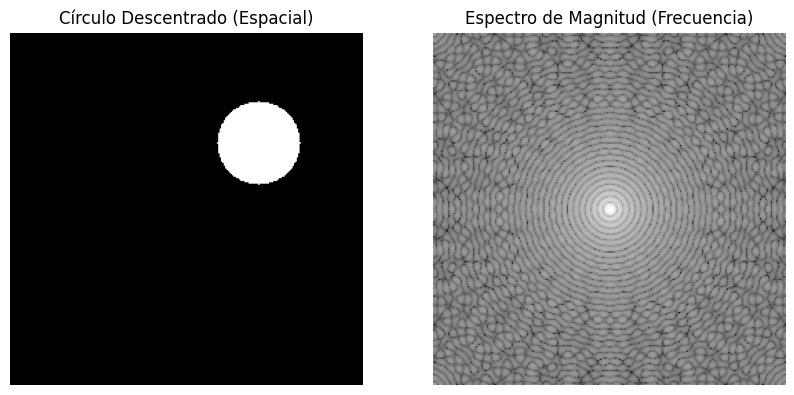


--- PUNTO 3: Rotación y Fenómenos de Borde ---


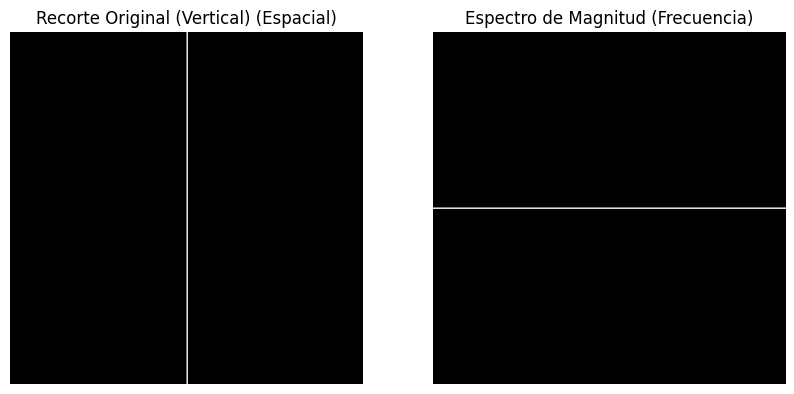

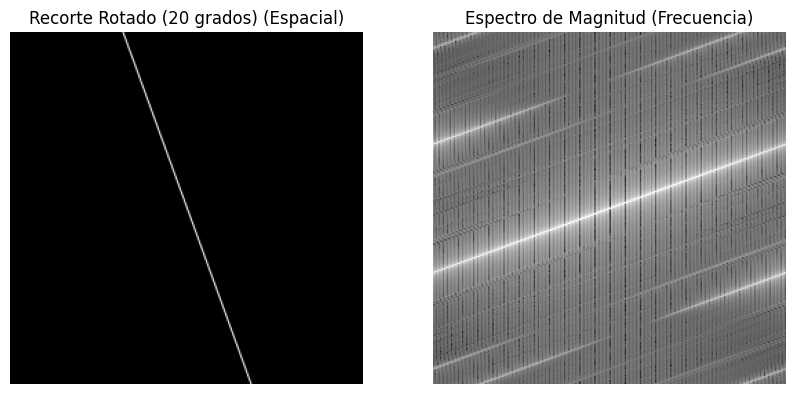

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import imutils

def calcular_y_mostrar_fft(img_espacial,titulo):
    # 1. Calcular la FFT de la imagen
    f = np.fft.fft2(img_espacial)
    # 2. Centrar las bajas frecuencias
    fshift = np.fft.fftshift(f)
    # 3. Calcular magnitud y aplicar logaritmo (sumamos 1 para no hacer log(0))
    magnitud = 20 * np.log(np.abs(fshift) + 1)
    
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(img_espacial, cmap='gray')
    axs[0].set_title(titulo + " (Espacial)")
    axs[0].axis('off')
    
    axs[1].imshow(magnitud, cmap='gray')
    axs[1].set_title("Espectro de Magnitud (Frecuencia)")
    axs[1].axis('off')
    plt.show()

print('--PUNTOS 1 Y 2: Formas basicas y TDF')

#Crear lienzo negros de 256x256
lienzo = lambda: np.zeros((256, 256), dtype=np.uint8)

#a) linea horizontal
img_h = lienzo()
cv2.line(img_h,(50,128),(206,128),255,5)
calcular_y_mostrar_fft(img_h, "Línea Horizontal")

# b) Línea Vertical
img_v = lienzo()
cv2.line(img_v, (128, 50), (128, 206), 255, 5)
calcular_y_mostrar_fft(img_v, "Línea Vertical")

# c) Cuadrado centrado
img_cuadrado = lienzo()
cv2.rectangle(img_cuadrado, (96, 96), (160, 160), 255, -1)
calcular_y_mostrar_fft(img_cuadrado, "Cuadrado")

# d) Círculo descentrado (Para comprobar que la TDF no cambia de lugar)
img_circulo = lienzo()
cv2.circle(img_circulo, (180, 80), 30, 255, -1)
calcular_y_mostrar_fft(img_circulo, "Círculo Descentrado")

print("\n--- PUNTO 3: Rotación y Fenómenos de Borde ---")

# Construir imagen 512x512 con línea vertical de 1 px
img_512 = np.zeros((512, 512), dtype=np.uint8)
cv2.line(img_512, (256, 0), (256, 512), 255, 1)

# Rotar 20 grados
img_rotada = imutils.rotate(img_512, 20)

# Extraer sección central de 256x256 (desde el pixel 128 al 384)
recorte_original = img_512[128:384, 128:384]
recorte_rotado = img_rotada[128:384, 128:384]

calcular_y_mostrar_fft(recorte_original, "Recorte Original (Vertical)")
calcular_y_mostrar_fft(recorte_rotado, "Recorte Rotado (20 grados)")

### Respuestas al Ejercicio 1: Conceptos básicos de la TDF 2D

**1 y 2. Pronósticos vs. Realidad (Formas Básicas)**
* **Línea Horizontal:** En el dominio frecuencial se observa una **línea vertical** centrada. Esto se debe a que los bordes espaciales generan altas frecuencias en dirección perpendicular.
* **Línea Vertical:** Se observa una **línea horizontal** centrada.
* **Cuadrado / Rectángulo:** Se observa un patrón en forma de cruz (matemáticamente, una función Sinc 2D). Las dimensiones son inversamente proporcionales: si el rectángulo es muy ancho en la imagen espacial, su espectro de magnitud será muy angosto en el eje X, y viceversa.
* **Círculo:** Se observan anillos concéntricos difuminados (discos de Airy).
* **Efecto de Traslación:** Si se varía la localización del objeto (por ejemplo, mover el cuadrado a una esquina), **el espectro de magnitud NO cambia**. La magnitud de la Transformada de Fourier es invariante a la traslación.

**3. La Línea Rotada (20 grados) y el Recorte**
* **Efecto de Rotación:** La propiedad de rotación de Fourier indica que si la imagen espacial se rota $\theta$ grados, el espectro de magnitud rotará exactamente esos mismos $\theta$ grados.
* **Diferencias originadas por el recorte:** Al recortar una sección de 256x256 donde la línea rota toca los bordes, se rompe la asunción de "periodicidad" matemática de Fourier. Como el algoritmo asume que la imagen se repite infinitamente como un mosaico, los extremos de la línea no encajan perfectamente con el "mosaico" de arriba y abajo. Ese desfase genera un "salto brusco" de intensidad, lo cual se traduce en altas frecuencias artificiales que ensucian el espectro (apareciendo como una cruz o línea adicional).


--- PUNTO 4: Correspondencia Frecuencial en Imágenes Reales ---


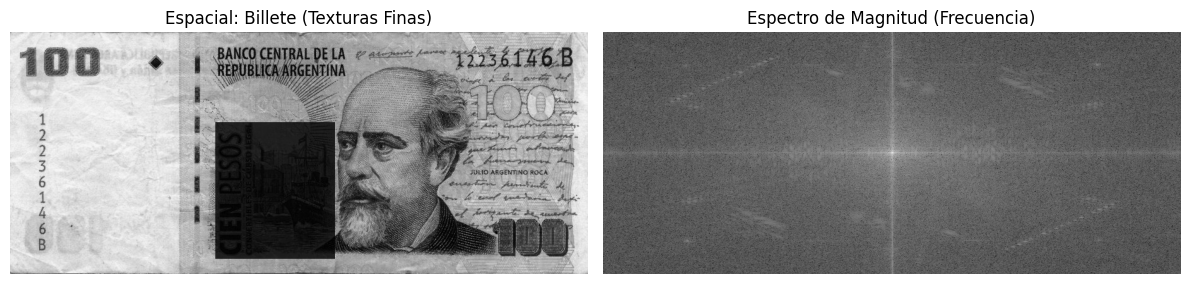

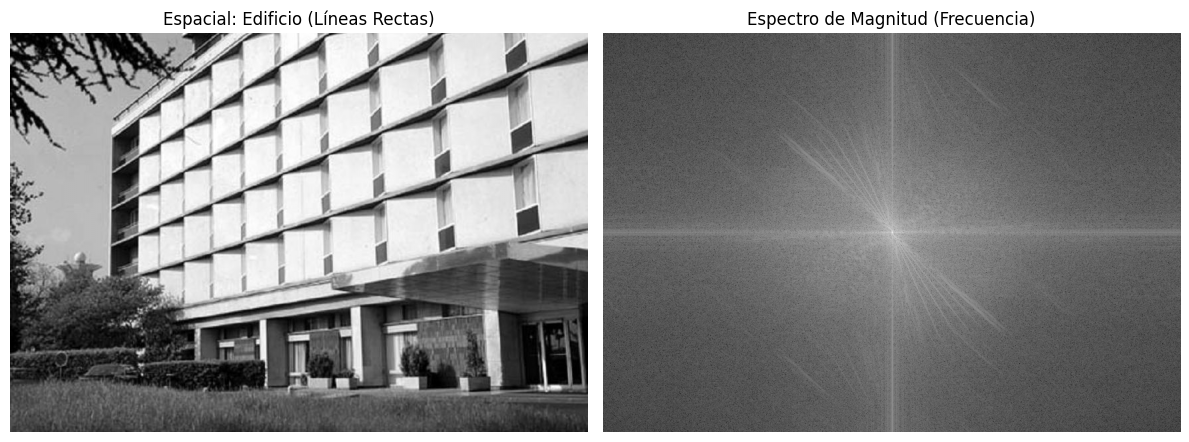

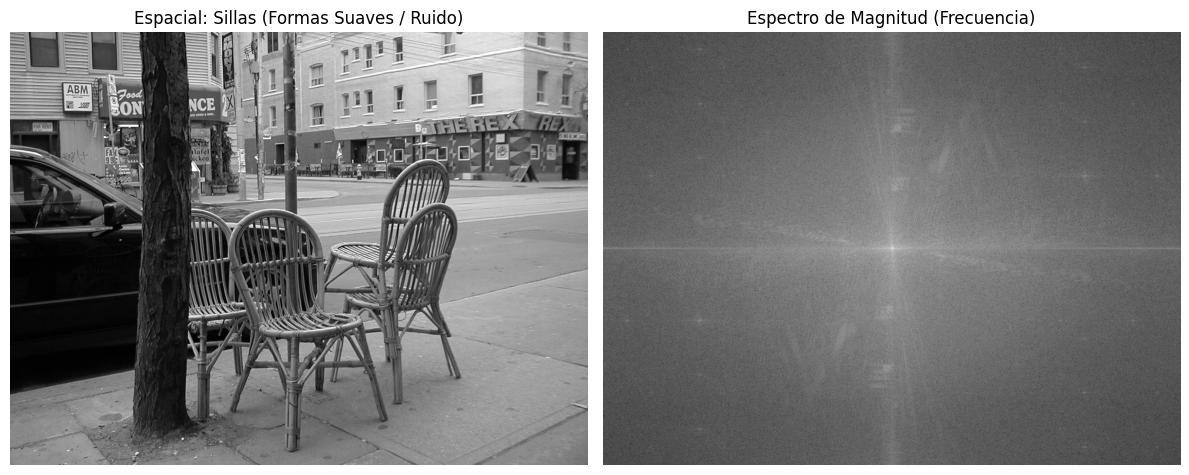

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def analizar_espectro(img_path, titulo):
    # Cargar en escala de grises
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"⚠️ No se encontró la imagen: {img_path}")
        return

    # 1. Calcular la TDF de la imagen real
    f = np.fft.fft2(img)
    
    # 2. Centrar las bajas frecuencias en el origen (el centro de la imagen)
    fshift = np.fft.fftshift(f)
    
    # 3. Calcular la magnitud (el módulo) y aplicar logaritmo para visualizar
    # Sumamos 1 para evitar problemas al hacer log(0)
    magnitud = 20 * np.log(np.abs(fshift) + 1)

    # Visualización
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    
    axs[0].imshow(img, cmap='gray')
    axs[0].set_title(f"Espacial: {titulo}")
    axs[0].axis('off')
    
    axs[1].imshow(magnitud, cmap='gray')
    axs[1].set_title("Espectro de Magnitud (Frecuencia)")
    axs[1].axis('off')
    
    plt.tight_layout()
    plt.show()

print("--- PUNTO 4: Correspondencia Frecuencial en Imágenes Reales ---")

# Ejecutamos el análisis para las 3 imágenes solicitadas
analizar_espectro('billete.jpg', 'Billete (Texturas Finas)')
analizar_espectro('building.jpg', 'Edificio (Líneas Rectas)')
analizar_espectro('chairs.jpg', 'Sillas (Formas Suaves / Ruido)')

**4. Componentes frecuenciales vs. Detalles de la imagen**
Al cargar imágenes reales, la correspondencia es la siguiente:
* **Bajas frecuencias (Centro del espectro):** Representan los cambios suaves de intensidad. Aquí vive la información del contraste general, la iluminación, los colores de fondo y las formas gruesas (siluetas).
* **Altas frecuencias (Alejadas del centro):** Representan los cambios bruscos de intensidad. Aquí se alojan los bordes de los objetos, las texturas finas, los detalles pequeños y el ruido de la imagen.